In [1]:
from __future__ import print_function
import tensorflow as tf
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Activation, Flatten
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.regularizers import l2
import numpy as np
import os
import matplotlib.pyplot as plt

%matplotlib inline

In [2]:
# batch, classes, epochs
batch_size = 32
num_classes = 10
epochs = 1

In [3]:
# The data, split between train and test sets:
(x_train, y_train), (x_test, y_test) = cifar10.load_data()
print("x_train shape:", x_train.shape)
print(x_train.shape[0], "train samples")
print(x_test.shape[0], "test samples")

x_train shape: (50000, 32, 32, 3)
50000 train samples
10000 test samples


In [4]:
x_train.shape

(50000, 32, 32, 3)

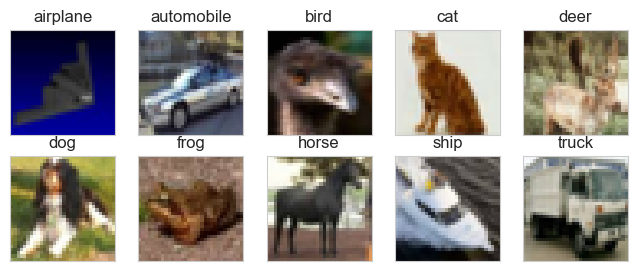

In [5]:
# plotting some random 10 images

class_names = [
    "airplane",
    "automobile",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck",
]

fig = plt.figure(figsize=(8, 3))
for i in range(num_classes):
    ax = fig.add_subplot(2, 5, 1 + i, xticks=[], yticks=[])
    idx = np.where(y_train[:] == i)[0]
    features_idx = x_train[idx, ::]
    img_num = np.random.randint(features_idx.shape[0])
    im = features_idx[img_num, ::]
    ax.set_title(class_names[i])
    plt.imshow(im)
plt.show()

In [6]:
# Convert class vectors to binary class matrices.
y_train = tf.keras.utils.to_categorical(y_train, num_classes)
y_test = tf.keras.utils.to_categorical(y_test, num_classes)

In [100]:
type(y_train)

numpy.ndarray

In [87]:
# model architecture
# model = Sequential()
# model.add(Conv2D(64, (3, 3), padding="same", input_shape=x_train.shape[1:]))
# model.add(Activation("relu"))
# model.add(BatchNormalization())
# model.add(Conv2D(32, (3, 3)))
# model.add(Activation("relu"))
# model.add(MaxPooling2D(pool_size=(2, 2)))
# model.add(Dropout(0.25))
#
# model.add(Conv2D(128, (3, 3), padding="same"))
# model.add(Activation("relu"))
# model.add(BatchNormalization())
# model.add(Conv2D(64, (3, 3)))
# model.add(Activation("relu"))
# model.add(MaxPooling2D(pool_size=(2, 2)))
# model.add(Dropout(0.25))
#
# model.add(Flatten())
# model.add(Dense(512))
# model.add(Activation("relu"))
# model.add(BatchNormalization())
# model.add(Dropout(0.5))
# model.add(Dense(num_classes))
# model.add(Activation("softmax"))

In [7]:
model = Sequential()
model.add(Conv2D(64, (3, 3), padding="same", input_shape=x_train.shape[1:]))
model.add(Activation("relu"))
model.add(BatchNormalization())
model.add(Conv2D(64, (3, 3)))
model.add(Activation("relu"))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))

model.add(Conv2D(128, (3, 3), padding="same"))
model.add(Activation("relu"))
model.add(BatchNormalization())
model.add(Conv2D(128, (3, 3)))
model.add(Activation("relu"))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))

model.add(Flatten())
model.add(Dense(512, kernel_regularizer=l2(0.01)))
model.add(Activation("relu"))
model.add(Dropout(0.5))
model.add(Dense(num_classes))
model.add(Activation("softmax"))

/Users/deven/.virtualenvs/ML_AI/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [82]:
# summary'
def write(file, info=None):
    with open(file, "w") as f:
        f.write(str(info))


model.summary(print_fn=lambda x: write("cifar.txt"))

In [ ]:
def out(file):
    with open(file, "w") as f:

        f.write(str(model.summary()))

In [8]:
# compile the model
model.compile(loss="categorical_crossentropy", optimizer="sgd", metrics=["accuracy"])

x_train = x_train.astype("float32")
x_test = x_test.astype("float32")

# Normalizing the input image
x_train /= 255
x_test /= 255

In [9]:
model.fit(
    x_train,
    y_train,
    batch_size=batch_size,
    epochs=epochs,
    validation_data=(x_test, y_test),
    shuffle=True,
    verbose=True,
)

 358/1563 ━━━━━━━━━━━━━━━━━━━━ 55s 46ms/step - accuracy: 0.2495 - loss: 11.5587

KeyboardInterrupt: 

In [44]:
str(model)

'<Sequential name=sequential_3, built=True>'

Result: After 50 epochs, the difference between training and validation accuracy is low but the training is slow as compared to the model with batch normalization.

In [45]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_18 (Activation)      │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 30, 30, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_19 (Activation)      │ (None, 30, 30, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 15, 15, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_20 (Activation)      │ (None, 15, 15, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 13, 13, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_21 (Activation)      │ (None, 13, 13, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 512)            │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_22 (Activation)      │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         5,130 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_23 (Activation)      │ (None, 10)             │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,752,576 (14.31 MB)

 Trainable params: 1,250,858 (4.77 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2,501,718 (9.54 MB)

In [46]:
model.get_compile_config()

{'optimizer': {'module': 'keras.optimizers',
  'class_name': 'Adam',
  'config': {'name': 'adam',
   'learning_rate': 0.0010000000474974513,
   'weight_decay': None,
   'clipnorm': None,
   'global_clipnorm': None,
   'clipvalue': None,
   'use_ema': False,
   'ema_momentum': 0.99,
   'ema_overwrite_frequency': None,
   'loss_scale_factor': None,
   'gradient_accumulation_steps': None,
   'beta_1': 0.9,
   'beta_2': 0.999,
   'epsilon': 1e-07,
   'amsgrad': False},
  'registered_name': None},
 'loss': 'categorical_crossentropy',
 'loss_weights': None,
 'metrics': ['accuracy'],
 'weighted_metrics': None,
 'run_eagerly': False,
 'steps_per_execution': 1,
 'jit_compile': False}

In [47]:
model.export("cifar.h5")

INFO:tensorflow:Assets written to: cifar.h5/assets


INFO:tensorflow:Assets written to: cifar.h5/assets


Saved artifact at 'cifar.h5'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 32, 32, 3), dtype=tf.float32, name='keras_tensor_363')
Output Type:
  TensorSpec(shape=(None, 10), dtype=tf.float32, name=None)
Captures:
  4520811728: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5555129040: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5555128080: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5555126928: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5555128656: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5555130384: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5555130768: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5555131152: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5555126736: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5555127888: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5555131536: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5555

In [49]:
model.save("cifar.keras")

In [52]:
print(model.history.keys())

AttributeError: 'History' object has no attribute 'keys'

In [56]:
for key, val in history.history.items():
    print(key, val)

accuracy [0.09613999724388123, 0.09917999804019928, 0.09836000204086304, 0.09860000014305115, 0.09644000232219696]
loss [2.302762746810913, 2.3027830123901367, 2.3027687072753906, 2.302781105041504, 2.3028056621551514]
val_accuracy [0.10000000149011612, 0.10000000149011612, 0.10000000149011612, 0.10000000149011612, 0.10000000149011612]
val_loss [2.3026273250579834, 2.302628993988037, 2.302628993988037, 2.302661418914795, 2.302640199661255]


In [63]:
list(model.history.history.items())

[('accuracy',
  [0.09613999724388123,
   0.09917999804019928,
   0.09836000204086304,
   0.09860000014305115,
   0.09644000232219696]),
 ('loss',
  [2.302762746810913,
   2.3027830123901367,
   2.3027687072753906,
   2.302781105041504,
   2.3028056621551514]),
 ('val_accuracy',
  [0.10000000149011612,
   0.10000000149011612,
   0.10000000149011612,
   0.10000000149011612,
   0.10000000149011612]),
 ('val_loss',
  [2.3026273250579834,
   2.302628993988037,
   2.302628993988037,
   2.302661418914795,
   2.302640199661255])]